In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from datetime import datetime # For time stamps to read data
from sklearn.preprocessing import MinMaxScaler # For scaling data
import seaborn as sns
from copy import deepcopy

In [40]:
#read data
train = pd.read_csv('../HW-04/hrl_load_metered.csv')
test1 = pd.read_csv('../HW-04/hrl_load_metered-test1.csv')
test2 = pd.read_csv('../HW-04/hrl_load_metered-test2.csv')
test3 = pd.read_csv('../HW-05/hrl_load_metered-test3.csv')
test4 = pd.read_csv('../HW-05/hrl_load_metered-test4.csv')
test5 = pd.read_csv('hrl_load_metered-test5.csv')

#format the datetime column
train['datetime_beginning_ept'] = pd.to_datetime(train['datetime_beginning_ept'], 
                                                  format='%m/%d/%y %H:%M', 
                                                  utc=True).dt.tz_convert('America/New_York')
test1['datetime_beginning_ept'] = pd.to_datetime(test1['datetime_beginning_ept'], 
                                                  format='%m/%d/%y %H:%M', 
                                                  utc=True).dt.tz_convert('America/New_York')
test2['datetime_beginning_ept'] = pd.to_datetime(test2['datetime_beginning_ept'], 
                                                  format='%m/%d/%y %H:%M', 
                                                  utc=True).dt.tz_convert('America/New_York')
test3['datetime_beginning_ept'] = pd.to_datetime(test3['datetime_beginning_ept'], 
                                                  format='%m/%d/%y %H:%M', 
                                                  utc=True).dt.tz_convert('America/New_York')
test4['datetime_beginning_ept'] = pd.to_datetime(test4['datetime_beginning_ept'], 
                                                  format='%m/%d/%y %H:%M', 
                                                  utc=True).dt.tz_convert('America/New_York')
test5['datetime_beginning_ept'] = pd.to_datetime(test5['datetime_beginning_ept'], 
                                                  format='%m/%d/%Y %I:%M:%S %p', 
                                                  utc=True).dt.tz_convert('America/New_York')

#create the train and test set
test = test5[['datetime_beginning_ept', 'mw']].copy()
train = pd.concat([train, test1, test2, test3, test4], ignore_index=True)
train = train[['datetime_beginning_ept', 'mw']].copy()
#add the train and test together with indicators
test['dataset'] = 'test'  # Add a column to indicate this is the test set
train['dataset'] = 'train'  # Add a column to indicate this is the test set
data = pd.concat([train, test], ignore_index=True)


In [45]:
data.head()

,datetime_beginning_ept,mw,dataset
0,2017-12-31 19:00:00-05:00,6787.226,train
1,2017-12-31 20:00:00-05:00,6909.472,train
2,2017-12-31 21:00:00-05:00,7004.748,train
3,2017-12-31 22:00:00-05:00,7093.771,train
4,2017-12-31 23:00:00-05:00,7244.769,train


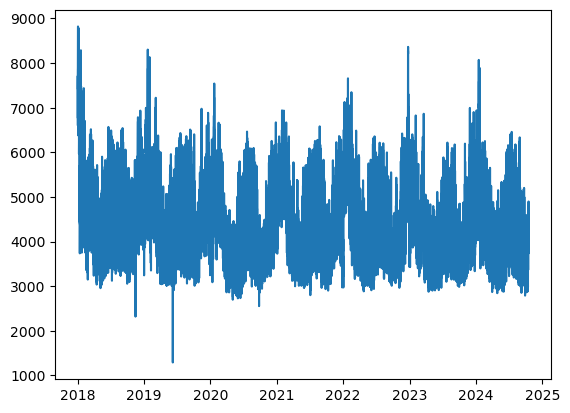

In [46]:
plt.plot(data['datetime_beginning_ept'], data['mw'])